## Step 1: Import Libraries and Configure Environment

In this step, we import all the required Python libraries used for training and evaluating the classification model.

These libraries support:

* **PyTorch and Torchvision** for deep learning models and training pipelines
* **Data loading utilities** such as `Dataset` and `DataLoader`
* **Image processing** using `PIL` and `torchvision.transforms`
* **Evaluation metrics** including Precision, Recall, F1-score, and AUC
* **Visualization tools** such as `matplotlib`
* **Mixed precision training** using `torch.amp` for faster GPU training

We also configure:

* **Reproducibility** by setting random seeds
* **cuDNN optimization** for faster convolution operations
* **Device selection** to utilize GPU if available


In [1]:
# ===============================
#  Imports
# ===============================

import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import GradScaler, autocast  # Mixed Precision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ===============================
#  Reproducibility
# ===============================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ===============================
#  Speed Optimization
# ===============================

# Allows cuDNN to find the best algorithm for your hardware
torch.backends.cudnn.benchmark = True

# ===============================
#  Device Configuration
# ===============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Step 2: Load Preprocessed Dataset

In this step, we load the **preprocessed dataset files** generated during the data preprocessing stage.

These files contain:

* **`train_samples.pt`** → training image paths and corresponding multi-label targets
* **`val_samples.pt`** → validation image paths and labels
* **`pos_weights.pt`** → class imbalance weights computed using the formula
  [
  pos_weight = \frac{N - P}{P}
  ]
  where *N* is total samples and *P* is number of positive samples per class.
* **`category_map.pt`** → mapping from original dataset category IDs to the 5 selected class indices.

The positive class weights are moved to the **GPU device** so they can be used directly in the **BCEWithLogitsLoss** function during training.

This dataset will be used for training the classification models, including **ResNet-50 and MobileNetV3**, ensuring a fair comparison by keeping the data and preprocessing identical across architectures.


In [2]:
# ===============================
#  Load Preprocessed Dataset
# ===============================

PREPROC_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed"

train_samples = torch.load(os.path.join(PREPROC_PATH, "train_samples.pt"), map_location="cpu")
val_samples = torch.load(os.path.join(PREPROC_PATH, "val_samples.pt"), map_location="cpu")
pos_weights = torch.load(os.path.join(PREPROC_PATH, "pos_weights.pt"), map_location="cpu")
category_map = torch.load(os.path.join(PREPROC_PATH, "category_map.pt"), map_location="cpu")

# Move weights to GPU for BCEWithLogitsLoss
pos_weights = pos_weights.to(device)

print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("Category mapping:", category_map)
print("Positive weights device:", pos_weights.device)

Train samples: 144174
Validation samples: 23741
Category mapping: {1: 0, 8: 1, 7: 2, 2: 3, 9: 4}
Positive weights device: cuda:0


## Step 3: Define Dataset Paths

In this step, we define the file paths for the **DeepFashion pruned dataset images**.

Although the labels and metadata were already preprocessed and saved earlier, the **actual images are still loaded from the original dataset directories**.

The following paths are defined:

* **Training images directory** → contains images used for model training
* **Validation images directory** → contains images used for validation during training

These directories will be used later in the custom dataset class to load images corresponding to the sample entries stored in the preprocessed dataset files.

This setup ensures that both **ResNet-50 and MobileNetV3 models use the same dataset and image sources**, enabling a fair comparison between architectures.


In [3]:
# ===============================
#  Dataset Paths
# ===============================

# Original pruned DeepFashion dataset
DATASET_PATH = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"

TRAIN_IMG_DIR = os.path.join(DATASET_PATH, "train", "images")
VAL_IMG_DIR   = os.path.join(DATASET_PATH, "validation", "images")

print("Train image directory:", TRAIN_IMG_DIR)
print("Validation image directory:", VAL_IMG_DIR)
print("Preprocessed dataset:", PREPROC_PATH)

Train image directory: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/train/images
Validation image directory: /kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset/validation/images
Preprocessed dataset: /kaggle/input/datasets/harshitabansal307/deepfashion-classification-preprocessed


## Step 4: Define Image Transformations

Before feeding images into the neural network, they must be transformed into a standardized format.

We apply different transformations for the **training** and **validation** datasets.

### Training Transformations

Training data uses **data augmentation** to improve model generalization and reduce overfitting. The following augmentations are applied:

* **RandomResizedCrop (224×224)**: Randomly crops and resizes the image to introduce scale variation.
* **RandomHorizontalFlip**: Randomly flips images horizontally with probability 0.5.
* **RandomRotation (±10°)**: Slight rotation to improve robustness to orientation changes.
* **ColorJitter**: Adjusts brightness, contrast, and saturation to simulate lighting variations.
* **ToTensor**: Converts images to PyTorch tensors.
* **Normalize**: Applies ImageNet normalization using predefined mean and standard deviation.

### Validation Transformations

Validation images are not augmented to ensure consistent evaluation. They are only:

* Resized to **224×224**
* Converted to tensors
* Normalized using ImageNet statistics

These transformations are compatible with pretrained CNN architectures such as **ResNet-50** and **MobileNetV3**, which expect images normalized with ImageNet statistics.


In [4]:
# ===============================
#  Image Transformations
# ===============================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Transforms defined successfully.")

Transforms defined successfully.


## Step 5: Define Custom Dataset Class

To efficiently load the DeepFashion dataset during training, we implement a custom PyTorch dataset class called `DeepFashionMultiLabelDataset`.

This class inherits from `torch.utils.data.Dataset` and performs the following operations:

* Stores the dataset samples consisting of `(image_path, label_vector)` pairs.
* Loads each image using the **PIL library**.
* Converts images to **RGB format** to ensure consistency.
* Applies the defined **image transformations** such as resizing, augmentation, and normalization.
* Converts the multi-label vector into a **PyTorch tensor of type `float32`**.

The `__getitem__` method returns:

* the transformed **image tensor**
* the corresponding **multi-label tensor**

This dataset class will later be used by the **DataLoader** to efficiently feed batches of images and labels into the neural network during training.

Since the dataset structure remains identical, this class works seamlessly for both **ResNet-50** and **MobileNetV3** classification models.


In [5]:
# ===============================
#  Custom Dataset Class
# ===============================

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


class DeepFashionMultiLabelDataset(Dataset):
    
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert("RGB")
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        # Convert label to tensor
        label = torch.tensor(label, dtype=torch.float32)
        
        return image, label

### Custom Dataset Class

Defines a PyTorch dataset for loading DeepFashion images and their multi-label targets.
It loads the image, applies transformations, and returns the image tensor and label vector.


In [6]:
# ===============================
#  Custom Dataset Class
# ===============================

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


class DeepFashionMultiLabelDataset(Dataset):
    
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception:
            # fallback in case image fails
            image = Image.new("RGB", (224, 224))

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label

### Create Dataset Objects

Creates training and validation dataset objects using the custom dataset class and applies the corresponding image transformations.


In [7]:
# ===============================
# Create Dataset Objects
# ===============================

train_dataset = DeepFashionMultiLabelDataset(
    train_samples,
    transform=train_transforms
)

val_dataset = DeepFashionMultiLabelDataset(
    val_samples,
    transform=val_transforms
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Train dataset size: 144174
Validation dataset size: 23741


## Step 6: Create DataLoaders

In this step, we create **PyTorch DataLoaders** for the training and validation datasets.
DataLoaders are responsible for efficiently loading data in **mini-batches** during model training.

### Handling Class Imbalance

Since the DeepFashion dataset is imbalanced (some clothing categories appear more frequently than others), we use a **WeightedRandomSampler** for the training set.

The sampler assigns a **weight to each training sample** based on its label vector and the previously computed **positive class weights (`pos_weights`)**.
Samples containing underrepresented classes receive higher weights, increasing their probability of being selected during training.

### DataLoader Configuration

**Training DataLoader**

* Uses the **WeightedRandomSampler** instead of random shuffling.
* Loads images in batches of size `BATCH_SIZE`.
* Utilizes multiple worker processes (`num_workers=4`) to speed up data loading.
* Enables `pin_memory=True` for faster GPU data transfer.

**Validation DataLoader**

* Does not use sampling or shuffling to ensure consistent evaluation.
* Loads validation data sequentially in batches.

This setup improves training stability and ensures that rare classes are sampled more frequently during training.


In [8]:
# ===============================
#  Create DataLoaders
# ===============================

from torch.utils.data import WeightedRandomSampler

BATCH_SIZE = 32  # Increase to 64 if GPU memory allows

# -------------------------------
# Compute sample weights
# -------------------------------
sample_weights = []
for _, label in train_samples:
    weight = sum(pos_weights[i].item() * label[i] for i in range(len(label))) + 1e-6
    sample_weights.append(weight)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# -------------------------------
# Train DataLoader
# -------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=4,
    pin_memory=True,
   # persistent_workers=True
)

# -------------------------------
# Validation DataLoader
# -------------------------------
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    #persistent_workers=True
)

print(f"DataLoaders ready with {len(train_loader)} batches per epoch.")

DataLoaders ready with 4506 batches per epoch.


## Step 7: Verify DataLoader Output

Before starting model training, it is good practice to verify that the **DataLoader is working correctly**.

In this step we:

* Fetch one batch from the training DataLoader.
* Check the **shape of the image batch** and **label batch**.
* Move the batch to the selected **training device (CPU/GPU)**.
* Confirm that both images and labels are correctly placed on the device.

This sanity check helps ensure that the data pipeline is functioning correctly before beginning model training.


In [9]:
try:
    images, labels = next(iter(train_loader))
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

    images = images.to(device)
    labels = labels.to(device)

    print("Device of images:", images.device)
    print("Device of labels:", labels.device)

except Exception as e:
    print("DataLoader check failed:", e)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32, 5])
Device of images: cuda:0
Device of labels: cuda:0


## Step 8: Build MobileNetV3 Model (Fine-Tuning)

In this step we initialize the **MobileNetV3-Large** model using pretrained weights from ImageNet.

Transfer learning is used to accelerate convergence and improve performance.
All layers are **unfrozen**, allowing the network to perform **full fine-tuning** on the DeepFashion dataset.

Since the original MobileNetV3 classifier is designed for **1000 ImageNet classes**, we replace the final layer with a new fully connected layer that outputs predictions for the **5 selected clothing categories**.

The model is then moved to the selected **training device (GPU/CPU)** for efficient training.


In [10]:
# ===============================
#  Build MobileNetV3 (Fine-Tuning)
# ===============================

NUM_CLASSES = len(category_map)

# Load pretrained MobileNetV3-Large
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2)

# Unfreeze ALL layers for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace final classification layer
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

# Move model to GPU
model = model.to(device)

print("MobileNetV3-Large (Fine-Tuning) ready.")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 128MB/s] 


MobileNetV3-Large (Fine-Tuning) ready.


## Step 9: Define Loss Function and Optimizer

In this step, we define the **loss function** and **optimizer** used for training the model.

Since the task is **multi-label classification**, we use **Binary Cross-Entropy with Logits Loss (`BCEWithLogitsLoss`)**.
This loss combines a sigmoid activation with binary cross-entropy and allows the model to predict multiple clothing categories for a single image.

To address **class imbalance**, the previously computed `pos_weights` are provided to the loss function. This increases the penalty for misclassifying underrepresented classes.

For optimization, we use the **Adam optimizer**, which adapts the learning rate for each parameter and typically converges faster for deep learning models. Only parameters with `requires_grad=True` are passed to the optimizer.

A small learning rate (`1e-5`) is used because we are performing **fine-tuning on a pretrained network**.


In [11]:
# ===============================
#  Loss and Optimizer
# ===============================

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Loss and optimizer ready.")

Loss and optimizer ready.


## Step 10: Model Training Loop

This step trains the classification model for a fixed number of epochs.

During training:

* The model processes mini-batches from the training DataLoader.
* **Mixed precision training (`autocast` + `GradScaler`)** is used to speed up GPU training and reduce memory usage.
* The loss is computed using **BCEWithLogitsLoss** for multi-label classification.

After each epoch, the model is evaluated on the validation dataset.
Predictions are converted to probabilities using **sigmoid**, and binary labels are obtained using a **0.5 threshold**.

The **macro F1-score** is used as the main evaluation metric.
Whenever the validation macro F1 improves, the current model weights are saved as the **best checkpoint**.

Finally, the best model (based on validation Macro F1) is loaded for further evaluation.


In [12]:
# ===============================
#  Training Loop
# ===============================

from tqdm import tqdm
import copy
from sklearn.metrics import f1_score

EPOCHS = 8

scaler = GradScaler("cuda")

best_macro_f1 = 0
best_model_weights = None

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ----- Training -----
    model.train()
    running_train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)


    # ----- Validation -----
    model.eval()
    running_val_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)

    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_model_weights = copy.deepcopy(model.state_dict())

        torch.save(
            model.state_dict(),
            "/kaggle/working/mobilenetv3_best_finetune.pth"
        )

print("\nTraining complete.")

model.load_state_dict(best_model_weights)
print("Best model loaded (based on Macro F1).")

Epoch 1/8: 100%|██████████| 4506/4506 [16:09<00:00,  4.65it/s]



Epoch [1/8]
Train Loss : 0.6891
Val Loss   : 0.5400
Macro F1   : 0.7166


Epoch 2/8: 100%|██████████| 4506/4506 [13:15<00:00,  5.66it/s]



Epoch [2/8]
Train Loss : 0.5364
Val Loss   : 0.4785
Macro F1   : 0.7481


Epoch 3/8: 100%|██████████| 4506/4506 [12:52<00:00,  5.83it/s]


...


Epoch [6/8]
Train Loss : 0.3982
Val Loss   : 0.4122
Macro F1   : 0.7830


Epoch 7/8: 100%|██████████| 4506/4506 [13:37<00:00,  5.51it/s]



Epoch [7/8]
Train Loss : 0.3761
Val Loss   : 0.4083
Macro F1   : 0.7889


Epoch 8/8: 100%|██████████| 4506/4506 [13:10<00:00,  5.70it/s]



Epoch [8/8]
Train Loss : 0.3595
Val Loss   : 0.3996
Macro F1   : 0.7947

Training complete.
Best model loaded (based on Macro F1).


## Step 11: Model Evaluation

This function evaluates the trained classification model on a dataset (typically the validation set).

It computes:

* **Per-class Precision, Recall, F1-score**
* **Macro and Micro F1-score**
* **ROC-AUC scores**
* **ROC curves for each clothing category**

Model outputs are converted to probabilities using **sigmoid**, and predictions are obtained using a **0.5 threshold** for multi-label classification.

These metrics help assess how well the model performs across all clothing categories.


In [13]:
# ===============================
#  Evaluation Function
# ===============================

def evaluate_model(model, data_loader):

    model.eval()

    all_labels = []
    all_outputs = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            all_labels.append(labels.cpu())
            all_outputs.append(outputs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_outputs = torch.cat(all_outputs)

    # Probabilities
    probs = torch.sigmoid(all_outputs).numpy()

    # Predictions
    preds = (probs > 0.5).astype(int)

    y_true = all_labels
    y_pred = preds
    y_prob = probs

    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)

    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_prob, average=None)
        macro_auc = roc_auc_score(y_true, y_prob, average="macro")
    except:
        roc_auc = [0]*len(category_map)
        macro_auc = 0

    print("\n===== Per Class Metrics =====")

    ordered_categories = list(category_map.values())

    for i in range(len(ordered_categories)):
        print(f"\nClass: {ordered_categories[i]}")
        print(f"Precision: {precision[i]:.4f}")
        print(f"Recall   : {recall[i]:.4f}")
        print(f"F1-score : {f1[i]:.4f}")
        print(f"AUC      : {roc_auc[i]:.4f}")

    print("\n===== Overall Metrics =====")
    print(f"Macro F1 : {macro_f1:.4f}")
    print(f"Micro F1 : {micro_f1:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")

    # ------------------------------
    # ROC Curves
    # ------------------------------
    from sklearn.metrics import roc_curve, auc

    plt.figure(figsize=(8,6))

    for i, class_name in enumerate(ordered_categories):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
        roc_auc_val = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc_val:.2f})")

    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Clothing Categories")
    plt.legend()
    plt.show()

    return macro_f1, micro_f1

### Final Model Evaluation

The trained model is evaluated on the validation dataset using the evaluation function defined earlier.
This computes the **Macro F1-score** and **Micro F1-score**, which summarize the model's performance across all clothing categories.


100%|██████████| 742/742 [01:27<00:00,  8.46it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.8593
Recall   : 0.8480
F1-score : 0.8536
AUC      : 0.9293

Class: 1
Precision: 0.8602
Recall   : 0.9228
F1-score : 0.8904
AUC      : 0.9724

Class: 2
Precision: 0.6082
Recall   : 0.8618
F1-score : 0.7131
AUC      : 0.9512

Class: 3
Precision: 0.6136
Recall   : 0.8972
F1-score : 0.7288
AUC      : 0.9302

Class: 4
Precision: 0.6870
Recall   : 0.9226
F1-score : 0.7875
AUC      : 0.9516

===== Overall Metrics =====
Macro F1 : 0.7947
Micro F1 : 0.8119
Macro AUC: 0.9469


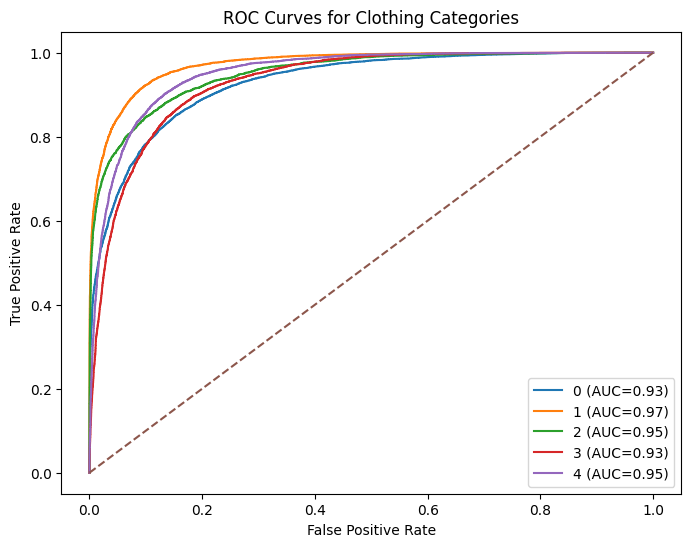


Final Validation Scores
Macro F1: 0.7946963556472234
Micro F1: 0.8119228938600667


In [14]:
macro_f1, micro_f1 = evaluate_model(model, val_loader)

print("\nFinal Validation Scores")
print("Macro F1:", macro_f1)
print("Micro F1:", micro_f1)

### Save Trained Model

The trained MobileNetV3 model is saved so it can be reused later for inference, evaluation, or comparison with other architectures.


In [15]:
# ===============================
# Save trained model
# ===============================

SAVE_PATH = "mobilenetv3_finetune_8epochs.pth"

torch.save(model.state_dict(), SAVE_PATH)

print(f"Model saved successfully at {SAVE_PATH}")

Model saved successfully at mobilenetv3_finetune_8epochs.pth


## Step 12: MobileNetV3 From Scratch

In this step, we initialize the **MobileNetV3-Large model without pretrained weights**.
Training from scratch allows the network to learn all parameters directly from the DeepFashion dataset.

The final classifier layer is replaced to output predictions for the **five clothing categories**, and its weights are initialized using **Xavier initialization** to improve training stability.


In [16]:
# ===============================
# MobileNetV3 From Scratch
# ===============================

scratch_model = models.mobilenet_v3_large(weights=None)

# Replace final classification layer
in_features = scratch_model.classifier[3].in_features
scratch_model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

# Initialize final layer
nn.init.xavier_uniform_(scratch_model.classifier[3].weight)
nn.init.zeros_(scratch_model.classifier[3].bias)

# Move model to GPU
scratch_model = scratch_model.to(device)

print("MobileNetV3 (Scratch) ready.")

MobileNetV3 (Scratch) ready.


## Step 13: Define Loss and Optimizer for Scratch Training

For training the MobileNetV3 model from scratch, we define the loss function and optimizer.

* **BCEWithLogitsLoss** is used for multi-label classification, allowing the model to predict multiple clothing categories per image.
* The previously computed **class imbalance weights (`pos_weights`)** are applied to penalize misclassification of underrepresented classes.
* The **Adam optimizer** is used with a slightly higher learning rate compared to fine-tuning, since the network is being trained from randomly initialized weights.
* **Weight decay** is added to help regularize the model and reduce overfitting.


In [17]:
# ===============================
# Loss & Optimizer (Scratch)
# ===============================

scratch_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

scratch_optimizer = torch.optim.Adam(
    scratch_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Scratch loss and optimizer ready.")

Scratch loss and optimizer ready.


## Step 14: Train MobileNetV3 From Scratch

In this step, the MobileNetV3 model initialized with **random weights** is trained on the DeepFashion dataset.

The training procedure follows the standard deep learning workflow:

* The model is trained for **8 epochs** using the training DataLoader.
* After each epoch, the model is evaluated on the **validation dataset**.
* Predictions are converted to probabilities using **sigmoid**, and binary predictions are obtained using a **0.5 threshold**.
* The **Macro F1-score** is used as the main evaluation metric.

The model weights corresponding to the **best Macro F1-score** on the validation set are saved and later restored as the final model.


In [18]:
# ===============================
# Scratch Training Loop
# ===============================

from sklearn.metrics import f1_score
import copy

EPOCHS = 8

best_macro_f1 = 0
best_scratch_weights = None

scratch_train_losses = []
scratch_val_losses = []

for epoch in range(EPOCHS):
    
    # ----- Training -----
    scratch_model.train()
    running_train_loss = 0.0
    
    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        scratch_optimizer.zero_grad()
        
        outputs = scratch_model(images)
        loss = scratch_criterion(outputs, labels)
        
        loss.backward()
        scratch_optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
    
    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    scratch_train_losses.append(epoch_train_loss)
    
    
    # ----- Validation -----
    scratch_model.eval()
    running_val_loss = 0.0
    
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = scratch_model(images)
            loss = scratch_criterion(outputs, labels)
            
            running_val_loss += loss.item() * images.size(0)
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
    
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    scratch_val_losses.append(epoch_val_loss)
    
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1:.4f}")
    
    
    # Save best model based on Macro F1
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_scratch_weights = copy.deepcopy(scratch_model.state_dict())

print("\nScratch Training complete.")

# Load best model
scratch_model.load_state_dict(best_scratch_weights)
print("Best scratch model loaded (based on Macro F1).")

100%|██████████| 4506/4506 [13:24<00:00,  5.60it/s]



Epoch [1/8]
Train Loss : 0.9133
Val Loss   : 0.8410
Macro F1   : 0.5109


100%|██████████| 4506/4506 [13:10<00:00,  5.70it/s]



Epoch [2/8]
Train Loss : 0.7995
Val Loss   : 0.7309
Macro F1   : 0.5909


100%|██████████| 4506/4506 [13:13<00:00,  5.68it/s]


...


Epoch [6/8]
Train Loss : 0.6174
Val Loss   : 0.5952
Macro F1   : 0.6799


100%|██████████| 4506/4506 [13:15<00:00,  5.66it/s]



Epoch [7/8]
Train Loss : 0.5964
Val Loss   : 0.5971
Macro F1   : 0.6822


100%|██████████| 4506/4506 [13:21<00:00,  5.62it/s]



Epoch [8/8]
Train Loss : 0.5734
Val Loss   : 0.5918
Macro F1   : 0.6876

Scratch Training complete.
Best scratch model loaded (based on Macro F1).


## Step 15: Evaluate MobileNetV3 Trained From Scratch

The MobileNetV3 model trained from scratch is evaluated on the validation dataset using the same evaluation function.
This provides the **Macro F1-score** and **Micro F1-score**, allowing comparison between fine-tuned and scratch-trained models.



===== MobileNetV3 Scratch Evaluation =====


100%|██████████| 742/742 [01:29<00:00,  8.33it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.7851
Recall   : 0.7607
F1-score : 0.7727
AUC      : 0.8560

Class: 1
Precision: 0.8110
Recall   : 0.8577
F1-score : 0.8337
AUC      : 0.9398

Class: 2
Precision: 0.4300
Recall   : 0.8406
F1-score : 0.5689
AUC      : 0.8962

Class: 3
Precision: 0.4490
Recall   : 0.8798
F1-score : 0.5946
AUC      : 0.8450

Class: 4
Precision: 0.5453
Recall   : 0.8621
F1-score : 0.6681
AUC      : 0.8828

===== Overall Metrics =====
Macro F1 : 0.6876
Micro F1 : 0.7044
Macro AUC: 0.8840


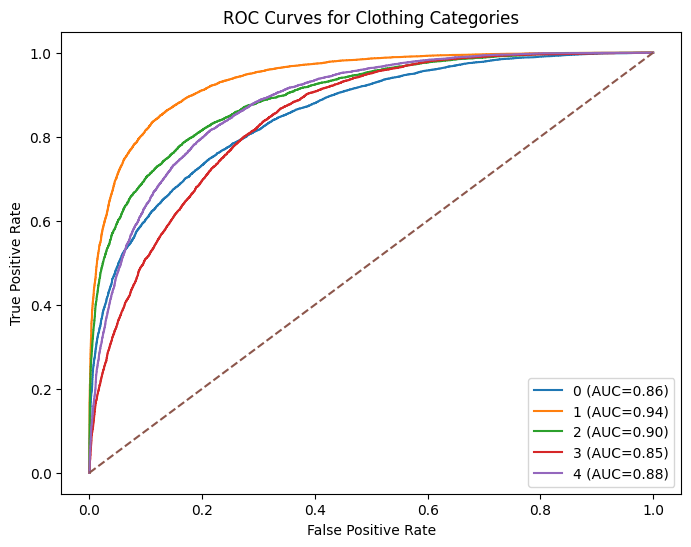


Final Scratch Results
Macro F1 : 0.6875903407639653
Micro F1 : 0.704429791565252


In [19]:
print("\n===== MobileNetV3 Scratch Evaluation =====")

macro_f1_scratch, micro_f1_scratch = evaluate_model(scratch_model, val_loader)

print("\nFinal Scratch Results")
print("Macro F1 :", macro_f1_scratch)
print("Micro F1 :", micro_f1_scratch)

### Save Scratch Model

The MobileNetV3 model trained from scratch is saved so it can be reused for inference or further evaluation.


In [21]:
torch.save(scratch_model.state_dict(), "mobilenetv3_scratch.pth")

## Step 16: MobileNetV3 Transfer Learning

In this step, we apply **transfer learning** using a pretrained MobileNetV3 model.

The pretrained backbone (feature extractor) is **frozen**, meaning its weights are not updated during training.
Only the **final classification layer** is replaced and trained to predict the five clothing categories.

This approach reduces training time and often improves performance when the dataset is relatively small.


In [22]:
# ===============================
# MobileNetV3 Transfer Learning
# ===============================

transfer_model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
)

# Freeze entire backbone
for param in transfer_model.parameters():
    param.requires_grad = False

# Replace classifier
in_features = transfer_model.classifier[3].in_features
transfer_model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

# Move model to GPU
transfer_model = transfer_model.to(device)

print("MobileNetV3 Transfer Learning ready.")

MobileNetV3 Transfer Learning ready.


## Step 17: Transfer Learning Loss and Optimizer

For transfer learning, only the **final classifier layer** is trained while the pretrained backbone remains frozen.

* **BCEWithLogitsLoss** is used for multi-label classification.
* Class imbalance is handled using the previously computed **positive class weights**.
* The optimizer updates **only the classifier parameters**, ensuring the pretrained feature extractor remains unchanged.


In [23]:
# ===============================
# Transfer Learning Loss & Optimizer
# ===============================

transfer_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

transfer_optimizer = torch.optim.Adam(
    transfer_model.classifier[3].parameters(),  # only classifier trains
    lr=1e-4
)

print("Transfer learning optimizer ready.")

Transfer learning optimizer ready.


## Step 18: Train MobileNetV3 Using Transfer Learning

In this step, the MobileNetV3 model is trained using **transfer learning**.

The pretrained backbone remains **frozen**, while only the **final classifier layer** is updated during training.

The training process follows these steps:

* The model is trained for multiple epochs using the training DataLoader.
* **Mixed precision training** (`autocast` and `GradScaler`) is used to speed up GPU computation.
* After each epoch, the model is evaluated on the validation dataset.
* The **Macro F1-score** is used as the main performance metric.
* The model weights corresponding to the **best validation Macro F1-score** are saved and restored after training.


In [24]:
# ===============================
# Transfer Learning Training
# ===============================

scaler = GradScaler("cuda")

best_transfer_weights = None
best_macro_f1_transfer = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # ----- Training -----
    transfer_model.train()
    running_train_loss = 0.0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        transfer_optimizer.zero_grad()

        with autocast(device_type="cuda"):
            outputs = transfer_model(images)
            loss = transfer_criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(transfer_optimizer)
        scaler.update()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # ----- Validation -----
    transfer_model.eval()
    running_val_loss = 0.0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = transfer_model(images)
            loss = transfer_criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)

    macro_f1_transfer = f1_score(all_labels, all_preds, average="macro")

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss : {epoch_train_loss:.4f}")
    print(f"Val Loss   : {epoch_val_loss:.4f}")
    print(f"Macro F1   : {macro_f1_transfer:.4f}")

    if macro_f1_transfer > best_macro_f1_transfer:
        best_macro_f1_transfer = macro_f1_transfer
        best_transfer_weights = copy.deepcopy(transfer_model.state_dict())

transfer_model.load_state_dict(best_transfer_weights)

print("Best transfer learning model loaded.")

100%|██████████| 4506/4506 [12:40<00:00,  5.93it/s]



Epoch [1/8]
Train Loss : 0.8492
Val Loss   : 0.7658
Macro F1   : 0.5869


100%|██████████| 4506/4506 [12:36<00:00,  5.95it/s]



Epoch [2/8]
Train Loss : 0.7981
Val Loss   : 0.7489
Macro F1   : 0.5934


100%|██████████| 4506/4506 [12:28<00:00,  6.02it/s]


...


Epoch [6/8]
Train Loss : 0.7811
Val Loss   : 0.7332
Macro F1   : 0.6021


100%|██████████| 4506/4506 [12:32<00:00,  5.99it/s]



Epoch [7/8]
Train Loss : 0.7785
Val Loss   : 0.7338
Macro F1   : 0.5991


100%|██████████| 4506/4506 [12:42<00:00,  5.91it/s]



Epoch [8/8]
Train Loss : 0.7785
Val Loss   : 0.7323
Macro F1   : 0.6030
Best transfer learning model loaded.



===== MobileNetV3 Transfer Learning Evaluation =====


100%|██████████| 742/742 [01:26<00:00,  8.60it/s]



===== Per Class Metrics =====

Class: 0
Precision: 0.7460
Recall   : 0.6245
F1-score : 0.6799
AUC      : 0.7718

Class: 1
Precision: 0.7265
Recall   : 0.7649
F1-score : 0.7452
AUC      : 0.8731

Class: 2
Precision: 0.3338
Recall   : 0.7849
F1-score : 0.4684
AUC      : 0.8030

Class: 3
Precision: 0.3762
Recall   : 0.8622
F1-score : 0.5239
AUC      : 0.7817

Class: 4
Precision: 0.4638
Recall   : 0.8409
F1-score : 0.5979
AUC      : 0.8221

===== Overall Metrics =====
Macro F1 : 0.6030
Micro F1 : 0.6139
Macro AUC: 0.8104


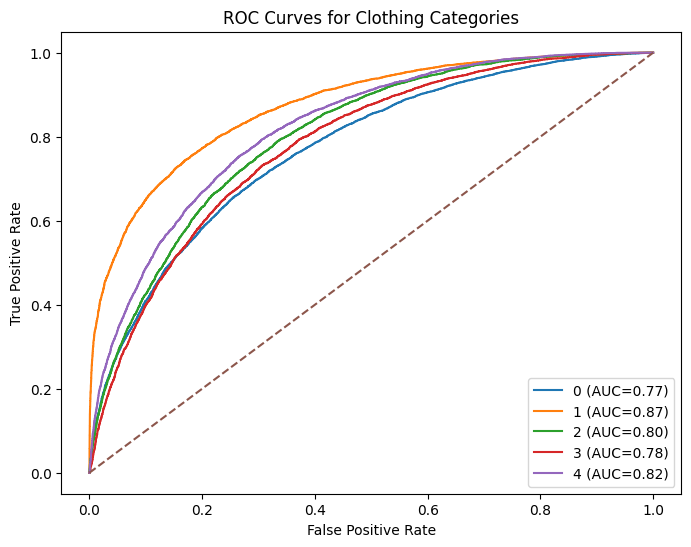


Final Transfer Learning Results
Macro F1 : 0.6030430877884767
Micro F1 : 0.6138662403410605


In [25]:
print("\n===== MobileNetV3 Transfer Learning Evaluation =====")

macro_f1_transfer, micro_f1_transfer = evaluate_model(transfer_model, val_loader)

print("\nFinal Transfer Learning Results")
print("Macro F1 :", macro_f1_transfer)
print("Micro F1 :", micro_f1_transfer)

### Save Transfer Learning Model

The MobileNetV3 model trained using transfer learning is saved so it can be reused later for inference or comparison with other models.


In [26]:
torch.save(transfer_model.state_dict(), "mobilenetv3_transfer_8epochs.pth")

### Final Model Comparison

This section summarizes the performance of the MobileNetV3 models trained using three strategies:

* Transfer Learning
* Fine-Tuning
* Training From Scratch

The comparison is based on **Macro F1-score** and **Micro F1-score**.


In [27]:
print("\n==============================")
print("        Final Model Comparison")
print("==============================")

print(f"{'Model':<25}{'Macro F1':<12}{'Micro F1':<12}")
print("-"*45)

print(f"{'MobileNetV3 Transfer':<25}{macro_f1_transfer:.4f}{'':<4}{micro_f1_transfer:.4f}")
print(f"{'MobileNetV3 Fine-Tune':<25}{macro_f1:.4f}{'':<4}{micro_f1:.4f}")
print(f"{'MobileNetV3 Scratch':<25}{macro_f1_scratch:.4f}{'':<4}{micro_f1_scratch:.4f}")


        Final Model Comparison
Model                    Macro F1    Micro F1    
---------------------------------------------
MobileNetV3 Transfer     0.6030    0.6139
MobileNetV3 Fine-Tune    0.6876    0.8119
MobileNetV3 Scratch      0.6876    0.7044
